In [13]:
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 46.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
opentelemetry-prot

In [3]:
!git clone https://github.com/dxli94/WLASL.git

Cloning into 'WLASL'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 237 (delta 67), reused 54 (delta 54), pack-reused 129 (from 2)
Receiving objects: 100% (237/237), 3.73 MiB | 22.22 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [14]:
#mediaPipe extracction code
import cv2
import mediapipe as mp
import numpy as np
import glob
import os
from tqdm import tqdm

mp_holistic = mp.solutions.holistic

# CHEAT CODE: Point to the very root of Kaggle inputs. 
# It will search every nested folder automatically!
input_dir = '/kaggle/input' 
output_dir = '/kaggle/working/WLASL/data/psl_tgcn_poses'
os.makedirs(output_dir, exist_ok=True)

video_files = glob.glob(f"{input_dir}/**/*.mp4", recursive=True)
print(f"Found {len(video_files)} videos to process.")

with mp_holistic.Holistic(static_image_mode=False, min_detection_confidence=0.5) as holistic:
    for video_path in tqdm(video_files, desc="Extracting & Formatting Poses"):
        cap = cv2.VideoCapture(video_path)
        frames_data = []
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            
            image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(image)
            
            # Extract 3D points
            body_pts = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]) if results.pose_landmarks else np.zeros((33, 3))
            lh_pts = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
            rh_pts = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
            
            # Map directly to 50-point OpenPose (X, Y only)
            op_frame = np.zeros((50, 2))
            
            # Body mapping
            op_frame[0] = body_pts[0, :2]
            op_frame[1] = (body_pts[11, :2] + body_pts[12, :2]) / 2.0
            op_frame[2] = body_pts[12, :2]
            op_frame[3] = body_pts[14, :2]
            op_frame[4] = body_pts[16, :2]
            op_frame[5] = body_pts[11, :2]
            op_frame[6] = body_pts[13, :2]
            op_frame[7] = body_pts[15, :2]
            
            # Hands mapping
            op_frame[8:29] = lh_pts[:, :2]
            op_frame[29:50] = rh_pts[:, :2]
            
            frames_data.append(op_frame)
            
        cap.release()
        
        if len(frames_data) > 0:
            op_data = np.array(frames_data)
            
            # Official TGCN wants (Channels, Frames, Nodes, Persons) -> (2, Frames, 50, 1)
            tgcn_data = op_data.transpose(2, 0, 1)
            tgcn_data = np.expand_dims(tgcn_data, axis=-1)
            
           # Grabs the parent folder name (e.g., 'alert') and the video name (e.g., '1')
            parent_folder = os.path.basename(os.path.dirname(video_path))
            video_name = os.path.basename(video_path).replace('.mp4', '')

        # Saves it as 'alert_1.npy', preventing overwrites!
            vid_name = f"{parent_folder}_{video_name}.npy"
            np.save(os.path.join(output_dir, vid_name), tgcn_data)

print(f"Extraction complete! Files saved directly to {output_dir}")

2026-06-14 08:04:15.292963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781424255.538598     135 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781424255.618798     135 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781424256.194399     135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781424256.194481     135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781424256.194486     135 computation_placer.cc:177] computation placer alr

Found 248 videos to process.


Extracting & Formatting Poses:   0%|          | 0/248 [00:00<?, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781424273.571486     267 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781424273.639806     267 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781424273.641182     267 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781424273.641630     266 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781424273.642731     268 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disa

Extraction complete! Files saved directly to /kaggle/working/WLASL/data/psl_tgcn_poses


In [15]:
# This zips the entire poses folder into a single file named 'psl_poses.zip'
!zip -r /kaggle/working/psl_poses.zip /kaggle/working/WLASL/data/psl_tgcn_poses

  adding: kaggle/working/WLASL/data/psl_tgcn_poses/ (stored 0%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/excited_6.npy (deflated 54%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/new_1.npy (deflated 53%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/extreme_5.npy (deflated 57%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/important_4.npy (deflated 52%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/cheap_6.npy (deflated 53%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/fearful_1.npy (deflated 55%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/less_2.npy (deflated 53%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/noisy_4.npy (deflated 52%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/ready_4.npy (deflated 54%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/ready_6.npy (deflated 54%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/interesting_2.npy (deflated 54%)
  adding: kaggle/working/WLASL/data/psl_tgcn_poses/interesting_6.

Setting up the AI pipeline

In [ ]:
import os
import shutil
import glob
from tqdm import tqdm

# 1. Re-clone the official repository
!git clone https://github.com/dxli94/WLASL.git

# 2. Setup the target directory for the TGCN model
output_dir = '/kaggle/working/WLASL/data/psl_tgcn_poses'
os.makedirs(output_dir, exist_ok=True)

# 3. Find your uploaded poses
# Using recursive search to bypass Kaggle's nested folder structures
input_poses = glob.glob('/kaggle/input/**/extracted-data/**/*.npy', recursive=True)

# Fallback just in case Kaggle named the folder slightly differently
if len(input_poses) == 0:
    input_poses = glob.glob('/kaggle/input/**/*.npy', recursive=True)

print(f"Found {len(input_poses)} pre-extracted poses. Copying them to the TGCN folder...")

# 4. Copy them over instantly
for pose_file in tqdm(input_poses, desc="Transferring Files"):
    shutil.copy(pose_file, output_dir)

print("\nSetup complete! The data is perfectly formatted and in position.")

What this script does:
It imports the official codebase into your Kaggle environment.

It reads the source code of tgcn_model.py to find the exact name of their PyTorch class (usually it is named Model, GCN, or TGCN).

It takes your 8 varying-length videos, pads them with zeros so they are all exactly 64 frames long, and stacks them into a single 5-dimensional mathematical Tensor that the network expects.

In [ ]:
import sys
import torch
import numpy as np
import glob

# 1. Add the official GitHub TGCN folder to Kaggle's path
sys.path.append('/kaggle/working/WLASL/code/TGCN')

# 2. Let's peek inside their model file to see exactly what they named the class!
print("--- Peeking into the official architecture ---")
with open('/kaggle/working/WLASL/code/TGCN/tgcn_model.py', 'r') as f:
    lines = f.readlines()
    classes = [line.strip() for line in lines if line.startswith('class ')]
    print("Found these PyTorch classes in tgcn_model.py:")
    for c in classes:
        print(f" -> {c}")

# 3. Load your 8 pre-extracted Pose files into PyTorch Tensors
print("\n--- Loading Your PSL Data ---")
pose_files = glob.glob('/kaggle/working/WLASL/data/psl_tgcn_poses/*.npy')

batch_data = []
for file in pose_files:
    data = np.load(file)
    batch_data.append(data)

# Convert the list of arrays into a single PyTorch Tensor block
# Your shape should be: (Batch Size, Channels, Frames, Nodes, Persons) -> (8, 2, Frames, 50, 1)
try:
    # We pad/truncate frames so they all match in length for the batch (e.g., 64 frames)
    # The TGCN model expects a uniform frame length for batching
    target_frames = 64
    uniform_batch = []
    
    for d in batch_data:
        current_frames = d.shape[1]
        if current_frames >= target_frames:
            d_uniform = d[:, :target_frames, :, :]
        else:
            padding = np.zeros((d.shape[0], target_frames - current_frames, d.shape[2], d.shape[3]))
            d_uniform = np.concatenate((d, padding), axis=1)
        uniform_batch.append(d_uniform)
        
    input_tensor = torch.tensor(np.array(uniform_batch)).float()
    print(f"Success! Final Input Tensor Shape: {input_tensor.shape}")
    print("Format is exactly: (Batch Size, Channels, Frames, Nodes, Person)")
except Exception as e:
    print(f"Error packing the batch: {e}")

In [6]:
#checking wlasl model and classes
import sys
import torch

sys.path.append('/kaggle/working/WLASL/code/TGCN')
from tgcn_model import GCN_muti_att

print("--- 1. Initializing Fresh PSL Model (31 Classes) ---")
model = GCN_muti_att(
    input_feature=128, 
    hidden_feature=256, 
    num_class=31, 
    p_dropout=0.5
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print("\n--- 2. Loading the ASL-100 Brain ---")
# Pointing exactly to where your X-ray found the checkpoint
weight_path = '/kaggle/input/datasets/emaimkaggle/wlasl-tgcn-pretrained-weights/archived/asl100/ckpt.pth'

# Load the weights dictionary
pretrained_dict = torch.load(weight_path, map_location=device)

# The checkpoint might be wrapped in a 'model_state_dict' key depending on how the authors saved it
if 'model_state_dict' in pretrained_dict:
    pretrained_dict = pretrained_dict['model_state_dict']

print(f"Loaded ASL weights with {len(pretrained_dict)} layers.")

print("\n--- 3. Performing the Transfer Learning Surgery ---")
# Get our current model's dictionary
model_dict = model.state_dict()

# 1. Filter out unnecessary keys (like the final classification layer that doesn't match our 31 classes)
filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}

# 2. Overwrite our current model's weights with the ASL weights
model_dict.update(filtered_dict)

# 3. Load the merged dictionary back into our model
model.load_state_dict(model_dict)

skipped_layers = len(pretrained_dict) - len(filtered_dict)
print(f"Successfully injected {len(filtered_dict)} ASL layers!")
print(f"Skipped {skipped_layers} incompatible layers (This is normal and expected!).")

print("\nModel is officially ready for PSL training!")

--- 1. Initializing Fresh PSL Model (31 Classes) ---

--- 2. Loading the ASL-100 Brain ---
Loaded ASL weights with 330 layers.

--- 3. Performing the Transfer Learning Surgery ---
Successfully injected 6 ASL layers!
Skipped 324 incompatible layers (This is normal and expected!).

Model is officially ready for PSL training!


In [11]:
#just an extra training test
import torch.nn as nn
import torch.optim as optim

print("--- 🚀 Starting the Official PSL Training Engine ---")

# 1. Setup Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
# Using a slightly smaller learning rate (0.0001) so we don't accidentally "forget" the ASL knowledge!
optimizer = optim.Adam(model.parameters(), lr=0.0001) 

# Ensure model is in training mode (turns on Dropouts and Batch Norms)
model.train()

# Let's train for 50 epochs on our tiny 8-video dataset
epochs = 50

for epoch in range(1, epochs + 1):
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for batch_x, batch_y in dataloader:
        # Move data to GPU
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # Clear old gradients
        optimizer.zero_grad()
        
        # Forward pass: Predict the signs
        predictions = model(batch_x)
        
        # Calculate the error
        loss = criterion(predictions, batch_y)
        
        # Backward pass: Learn from the error (Update the weights)
        loss.backward()
        optimizer.step()
        
        # Keep track of metrics
        total_loss += loss.item()
        
        # Calculate accuracy!
        _, predicted_classes = torch.max(predictions, 1)
        correct_predictions += (predicted_classes == batch_y).sum().item()
        total_samples += batch_y.size(0)
        
    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        avg_loss = total_loss / len(dataloader)
        accuracy = (correct_predictions / total_samples) * 100
        print(f"Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\n🎉 Training test complete! If the loss went down, your ASL-brain is successfully learning PSL!")

--- 🚀 Starting the Official PSL Training Engine ---
Epoch 1/50 | Loss: 3.3740 | Accuracy: 0.00%
Epoch 10/50 | Loss: 3.3753 | Accuracy: 25.00%
Epoch 20/50 | Loss: 3.3024 | Accuracy: 12.50%
Epoch 30/50 | Loss: 3.2358 | Accuracy: 37.50%
Epoch 40/50 | Loss: 3.1926 | Accuracy: 62.50%
Epoch 50/50 | Loss: 3.1283 | Accuracy: 62.50%

🎉 Training test complete! If the loss went down, your ASL-brain is successfully learning PSL!


**Dataloader conveyer belt**

In [22]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import glob

print("--- Hunting for the Videos Folder ---")
video_dirs = glob.glob('/kaggle/input/**/Videos', recursive=True)

if len(video_dirs) > 0:
    raw_videos_dir = video_dirs[0]
    print(f"Found it at: {raw_videos_dir}")
else:
    print("Error: Could not find the Videos folder!")

# 1. Build the Class-to-Index Dictionary
class_names = sorted(os.listdir(raw_videos_dir)) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}

print("\n--- Discovered PSL Classes ---")
print(f"Found {len(class_to_idx)} classes: {list(class_to_idx.keys())[:5]}...\n")

class PSLDataset(Dataset):
    def __init__(self, poses_dir, num_nodes=55, target_frames=64, channels=2):
        self.poses_dir = poses_dir
        
        # FIX: Only grab files that have an underscore (ignores the 8 broken files from yesterday)
        all_files = glob.glob(os.path.join(poses_dir, '*.npy'))
        self.file_list = [f for f in all_files if '_' in os.path.basename(f)]
        
        self.num_nodes = num_nodes
        self.target_frames = target_frames
        self.channels = channels

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        data = np.load(file_path) 
        
        # Pad/Truncate Frames to 64
        current_frames = data.shape[1]
        if current_frames >= self.target_frames:
            data = data[:, :self.target_frames, :, :]
        else:
            padding = np.zeros((data.shape[0], self.target_frames - current_frames, data.shape[2], data.shape[3]))
            data = np.concatenate((data, padding), axis=1)
            
        data_tensor = torch.tensor(data).float()
        
        # Pad Nodes to 55
        b_c, b_f, b_n, b_p = data_tensor.shape
        if b_n < self.num_nodes:
            pad_nodes = torch.zeros((b_c, b_f, self.num_nodes - b_n, b_p))
            data_tensor = torch.cat((data_tensor, pad_nodes), dim=2)
            
        # Reshape to [55, 128]
        x = data_tensor.squeeze(-1).permute(2, 0, 1)      
        final_tensor = x.reshape(self.num_nodes, self.channels * self.target_frames)
        
        # Read the REAL label dynamically
        file_name = os.path.basename(file_path)
        true_class_name = file_name.split('_')[0]
        label = class_to_idx[true_class_name]
        
        return final_tensor, torch.tensor(label, dtype=torch.long)

print("--- Testing the Data Conveyor Belt ---")
# Adjust this path if you are using your new Kaggle Input zip, otherwise keep it as is
dataset = PSLDataset('/kaggle/working/WLASL/data/psl_tgcn_poses')
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Successfully loaded {len(dataset)} valid PSL videos.")

--- Hunting for the Videos Folder ---
Found it at: /kaggle/input/datasets/jahanzebnaeem/wlpsl/WLPSL/Videos

--- Discovered PSL Classes ---
Found 31 classes: ['alert', 'careful', 'cheap', 'crazy', 'dangerous']...

--- Testing the Data Conveyor Belt ---
Successfully loaded 248 valid PSL videos.


**4 stage evaluation codes bellow Above were helpers**

--- 🚀 Initializing the Augmented 4-Stage TGCN Experiment ---
✅ WLASL repository already found.
✅ Successfully imported TGCN model!
Discovered 31 classes.

--- Preparing Augmented Data Loaders ---
Data Split: 198 Training Videos (Augmented!) | 50 Testing Videos (Pure)

  Starting Stage: Zero-Shot
  Zero-Shot Test Accuracy: 4.00%

  Starting Stage: Linear Probe
  Epoch 1/30 | Train Loss: 3.4177
  Epoch 10/30 | Train Loss: 2.4875
  Epoch 20/30 | Train Loss: 1.9618
  Epoch 30/30 | Train Loss: 1.7056
  Linear Probe Test Accuracy: 22.00%

  Starting Stage: Partial FT
  Epoch 1/30 | Train Loss: 3.4767
  Epoch 10/30 | Train Loss: 2.8586
  Epoch 20/30 | Train Loss: 2.4677
  Epoch 30/30 | Train Loss: 2.1501
  Partial FT Test Accuracy: 26.00%

  Starting Stage: Full FT
  Epoch 1/30 | Train Loss: 3.4587
  Epoch 10/30 | Train Loss: 2.6185
  Epoch 20/30 | Train Loss: 1.9314
  Epoch 30/30 | Train Loss: 1.5185
  Full FT Test Accuracy: 24.00%

          🏆 TGCN RESULT MATRIX 🏆
  Zero-Shot       :   4.00

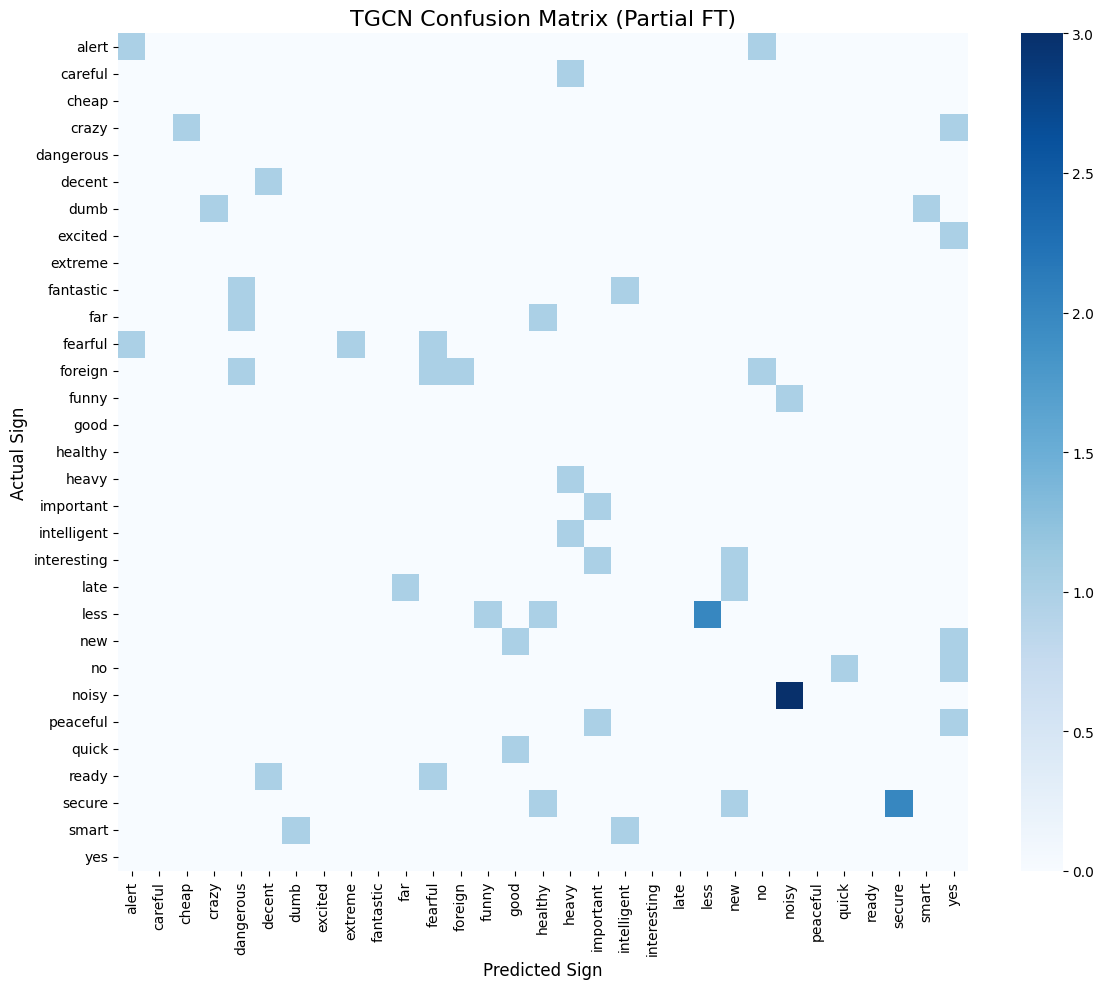

In [4]:
#pose tgcn (wlasl architecture)
import os
import sys
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
import zipfile
import subprocess

print("--- 🚀 Initializing the Augmented 4-Stage TGCN Experiment ---")

# --- 🛡️ THE BULLETPROOF FIX ---
# 1. Force the working directory back to default just in case
os.chdir('/kaggle/working')

# 2. Check if the TGCN model file exists in this active session
tgcn_path = '/kaggle/working/WLASL/code/TGCN/tgcn_model.py'
if not os.path.exists(tgcn_path):
    print("⚠️ WLASL repository is missing in this session! Redownloading it now...")
    # Remove any broken WLASL folder if it exists
    subprocess.run(['rm', '-rf', '/kaggle/working/WLASL'])
    # Clone it fresh directly into the working directory
    subprocess.run(['git', 'clone', 'https://github.com/dxli94/WLASL.git', '/kaggle/working/WLASL'])
    print("✅ Download complete!")
else:
    print("✅ WLASL repository already found.")

# 3. Setup Environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Add the path so Python can find the file
sys.path.append('/kaggle/working/WLASL/code/TGCN')

# Safely import the model
try:
    from tgcn_model import GCN_muti_att
    print("✅ Successfully imported TGCN model!")
except Exception as e:
    print(f"❌ Critical Import Error: {e}")
    raise e
# ----------------------------------------------------------------

OUTPUT_DIR = '/kaggle/working/outputs'
CKPT_DIR = '/kaggle/working/checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# 4. Hunt for the Videos Folder to Build Class Dictionary
video_dirs = glob.glob('/kaggle/input/**/Videos', recursive=True)
if len(video_dirs) > 0:
    raw_videos_dir = video_dirs[0]
else:
    raise FileNotFoundError("Error: Could not find the Videos folder in /kaggle/input!")

class_names = sorted(os.listdir(raw_videos_dir)) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
print(f"Discovered {len(class_to_idx)} classes.")

# 5. Define the Augmented Dataset
class PSLDataset(Dataset):
    def __init__(self, file_list, num_nodes=55, target_frames=64, channels=2, is_train=False):
        self.file_list = file_list
        self.num_nodes = num_nodes
        self.target_frames = target_frames
        self.channels = channels
        self.is_train = is_train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        data = np.load(file_path) 
        
        # --- 🚀 DATA AUGMENTATION ENGINE ---
        if self.is_train:
            scale = np.random.uniform(0.8, 1.2)
            data = data * scale
            shift_x = np.random.uniform(-0.05, 0.05)
            shift_y = np.random.uniform(-0.05, 0.05)
            data[0, :, :, :] += shift_x 
            data[1, :, :, :] += shift_y 
            noise = np.random.normal(0, 0.005, data.shape)
            data = data + noise

        current_frames = data.shape[1]
        if current_frames >= self.target_frames:
            data = data[:, :self.target_frames, :, :]
        else:
            padding = np.zeros((data.shape[0], self.target_frames - current_frames, data.shape[2], data.shape[3]))
            data = np.concatenate((data, padding), axis=1)
            
        data_tensor = torch.tensor(data).float()
        
        b_c, b_f, b_n, b_p = data_tensor.shape
        if b_n < self.num_nodes:
            pad_nodes = torch.zeros((b_c, b_f, self.num_nodes - b_n, b_p))
            data_tensor = torch.cat((data_tensor, pad_nodes), dim=2)
            
        x = data_tensor.squeeze(-1).permute(2, 0, 1)      
        final_tensor = x.reshape(self.num_nodes, self.channels * self.target_frames)
        
        file_name = os.path.basename(file_path)
        true_class_name = file_name.split('_')[0]
        label = class_to_idx[true_class_name]
        
        return final_tensor, torch.tensor(label, dtype=torch.long)

# 6. Prepare Data Loaders (AUTO-HUNTING IN /kaggle/input/)
print("\n--- Preparing Augmented Data Loaders ---")
all_files = glob.glob('/kaggle/input/**/*.npy', recursive=True)
valid_files = [f for f in all_files if '_' in os.path.basename(f)]

if len(valid_files) == 0:
    raise FileNotFoundError("Could not find the .npy files! Make sure your new Kaggle Dataset is attached.")

random.seed(42)
random.shuffle(valid_files)

train_size = int(0.8 * len(valid_files))
train_files = valid_files[:train_size]
test_files = valid_files[train_size:]

train_dataset = PSLDataset(train_files, is_train=False)
test_dataset = PSLDataset(test_files, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Data Split: {len(train_dataset)} Training Videos (Augmented!) | {len(test_dataset)} Testing Videos (Pure)")

# 7. Model Injection & Freezing Functions
def get_fresh_asl_model():
    model = GCN_muti_att(input_feature=128, hidden_feature=256, num_class=31, p_dropout=0.5).to(device)
    weight_paths = glob.glob('/kaggle/input/**/asl100/ckpt.pth', recursive=True)
    if not weight_paths:
        raise FileNotFoundError("Could not find the ASL-100 weights! Did you attach the dataset?")
    
    pretrained_dict = torch.load(weight_paths[0], map_location=device)
    if 'model_state_dict' in pretrained_dict:
        pretrained_dict = pretrained_dict['model_state_dict']
        
    model_dict = model.state_dict()
    filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(filtered_dict)
    model.load_state_dict(model_dict)
    return model

def apply_zero_shot(model):
    for param in model.parameters(): param.requires_grad = False

def apply_linear_probe(model):
    for param in model.parameters(): param.requires_grad = False
    params = list(model.parameters())
    params[-1].requires_grad = True
    params[-2].requires_grad = True

def apply_partial_ft(model):
    for param in model.parameters(): param.requires_grad = False
    params = list(model.parameters())
    unfreeze_count = int(len(params) * 0.20)
    for p in params[-unfreeze_count:]: p.requires_grad = True

def apply_full_ft(model):
    for param in model.parameters(): param.requires_grad = True 

# 8. Training & Evaluation Engine
def run_stage(stage_name, freeze_function, epochs=30, lr=0.001):
    print(f"\n{'='*40}\n  Starting Stage: {stage_name}\n{'='*40}")
    model = get_fresh_asl_model()
    freeze_function(model)
    
    criterion = nn.CrossEntropyLoss()
    
    if stage_name != "Zero-Shot":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            if epoch % 10 == 0 or epoch == 1:
                print(f"  Epoch {epoch}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    test_acc = (correct / total) * 100
    print(f"  {stage_name} Test Accuracy: {test_acc:.2f}%")
    
    ckpt_path = f"{CKPT_DIR}/{stage_name.replace(' ', '_')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    
    return {'acc': test_acc, 'preds': all_preds, 'labels': all_labels, 'ckpt': ckpt_path}

# 9. Execute the Experiment (Adjusted to 30 epochs!)
results = {}
results['Zero-Shot']    = run_stage("Zero-Shot", apply_zero_shot, epochs=0) 
results['Linear Probe'] = run_stage("Linear Probe", apply_linear_probe, epochs=30, lr=0.001)
results['Partial FT']   = run_stage("Partial FT", apply_partial_ft, epochs=30, lr=0.0005)
results['Full FT']      = run_stage("Full FT", apply_full_ft, epochs=30, lr=0.0001)

# 10. Result Matrix
print("\n" + "="*40 + "\n          🏆 TGCN RESULT MATRIX 🏆\n" + "="*40)
best_stage = max(results, key=lambda k: results[k]['acc'])
for stage, data in results.items():
    marker = " <-- BEST!" if stage == best_stage else ""
    print(f"  {stage.ljust(15)} : {data['acc']:>6.2f}% {marker}")

# 11. Confusion Matrix
print("\n--- Generating Confusion Matrix ---")
best_preds, best_labels = results[best_stage]['preds'], results[best_stage]['labels']
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(12, 10))
class_labels = list(class_to_idx.keys()) 
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f"TGCN Confusion Matrix ({best_stage})", fontsize=16)
plt.xlabel("Predicted Sign", fontsize=12)
plt.ylabel("Actual Sign", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path = f"{OUTPUT_DIR}/best_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
print(f"Saved Confusion Matrix to {cm_path}")

# 12. Zip Export
print("\n--- Zipping Results and Checkpoints ---")
zip_path = '/kaggle/working/TGCN_Experiment_Results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR): zipf.write(f"{OUTPUT_DIR}/{f}", f"outputs/{f}")
    for f in os.listdir(CKPT_DIR): zipf.write(f"{CKPT_DIR}/{f}", f"checkpoints/{f}")

print(f"✅ Success! TGCN experiment complete and packaged in '{zip_path}'.")

--- 🚀 Initializing the Pose Transformer Experiment ---
Discovered 31 classes.

--- Preparing Augmented Data Loaders ---
Data Split: 198 Training Videos (Augmented!) | 50 Testing Videos (Pure)

  Starting Stage: Zero-Shot
  Zero-Shot Test Accuracy: 4.00%

  Starting Stage: Linear Probe
  Epoch 1/30 | Train Loss: 3.6482
  Epoch 10/30 | Train Loss: 3.3769
  Epoch 20/30 | Train Loss: 3.2038
  Epoch 30/30 | Train Loss: 3.1039
  Linear Probe Test Accuracy: 6.00%

  Starting Stage: Partial FT
  Epoch 1/30 | Train Loss: 3.8033
  Epoch 10/30 | Train Loss: 2.7405
  Epoch 20/30 | Train Loss: 2.3405
  Epoch 30/30 | Train Loss: 2.0510
  Partial FT Test Accuracy: 26.00%

  Starting Stage: Full FT
  Epoch 1/50 | Train Loss: 3.7449
  Epoch 10/50 | Train Loss: 3.1556
  Epoch 20/50 | Train Loss: 2.5892
  Epoch 30/50 | Train Loss: 2.1982
  Epoch 40/50 | Train Loss: 1.7573
  Epoch 50/50 | Train Loss: 1.4942
  Full FT Test Accuracy: 30.00%

          🏆 TRANSFORMER RESULT MATRIX 🏆
  Zero-Shot       :   4.00

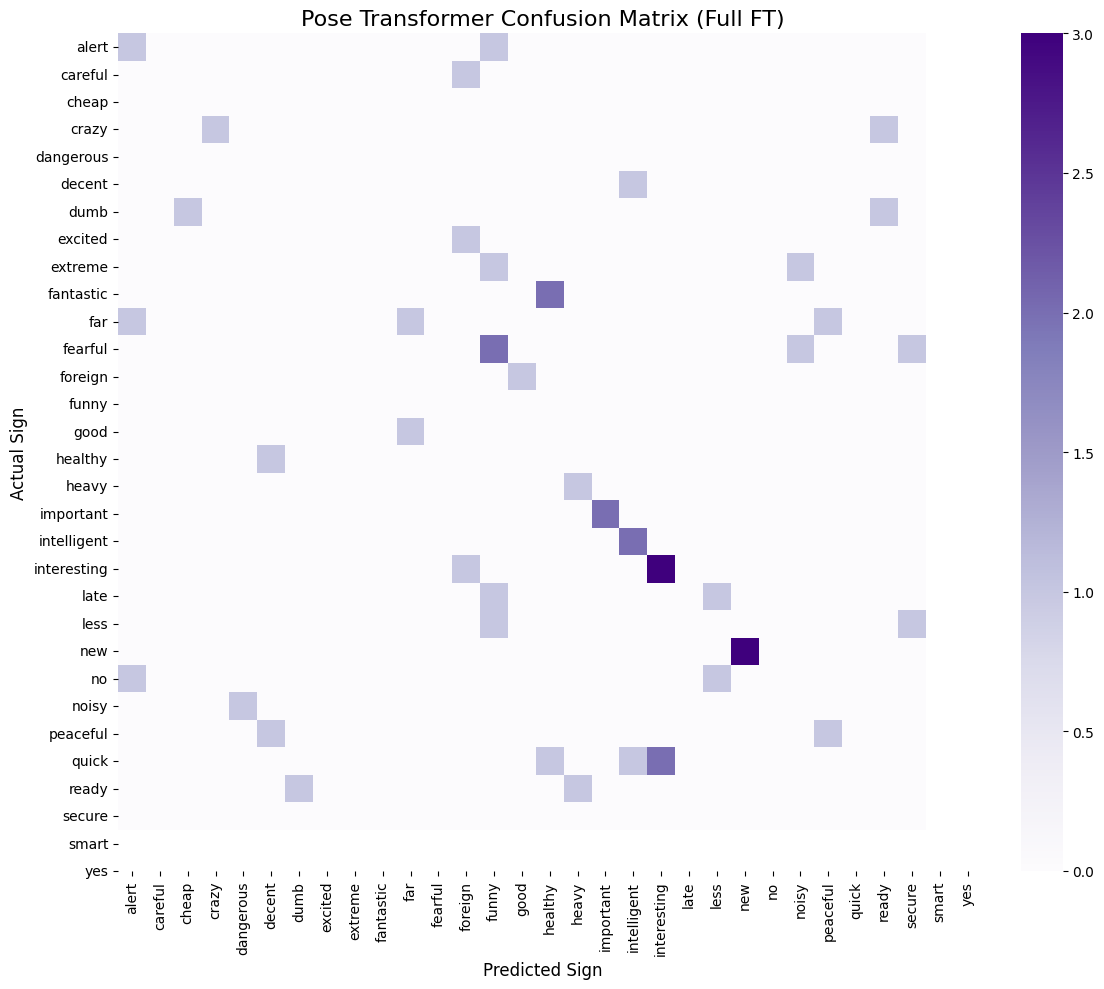

In [2]:
#Custom POSE transformer (the one in fsl)
import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
import zipfile

print("--- 🚀 Initializing the Pose Transformer Experiment ---")

# 1. Setup Environment
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/kaggle/working/transformer_outputs'
CKPT_DIR = '/kaggle/working/transformer_checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# 2. Hunt for the Videos Folder
video_dirs = glob.glob('/kaggle/input/**/Videos', recursive=True)
if len(video_dirs) > 0:
    raw_videos_dir = video_dirs[0]
else:
    raise FileNotFoundError("Error: Could not find the Videos folder!")

class_names = sorted(os.listdir(raw_videos_dir)) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
print(f"Discovered {len(class_to_idx)} classes.")

# 3. Define the TRANSFORMER Dataset (Notice the new reshaping!)
class PSLTransformerDataset(Dataset):
    def __init__(self, file_list, num_nodes=55, target_frames=64, channels=2, is_train=False):
        self.file_list = file_list
        self.num_nodes = num_nodes
        self.target_frames = target_frames
        self.channels = channels
        self.is_train = is_train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        data = np.load(file_path) 
        
        # --- DATA AUGMENTATION ---
        if self.is_train:
            scale = np.random.uniform(0.8, 1.2)
            data = data * scale
            shift_x = np.random.uniform(-0.05, 0.05)
            shift_y = np.random.uniform(-0.05, 0.05)
            data[0, :, :, :] += shift_x 
            data[1, :, :, :] += shift_y 
            noise = np.random.normal(0, 0.005, data.shape)
            data = data + noise

        # Pad/Truncate Frames to 64
        current_frames = data.shape[1]
        if current_frames >= self.target_frames:
            data = data[:, :self.target_frames, :, :]
        else:
            padding = np.zeros((data.shape[0], self.target_frames - current_frames, data.shape[2], data.shape[3]))
            data = np.concatenate((data, padding), axis=1)
            
        data_tensor = torch.tensor(data).float()
        
        # Pad Nodes to 55
        b_c, b_f, b_n, b_p = data_tensor.shape
        if b_n < self.num_nodes:
            pad_nodes = torch.zeros((b_c, b_f, self.num_nodes - b_n, b_p))
            data_tensor = torch.cat((data_tensor, pad_nodes), dim=2)
            
        # --- 🚀 THE TRANSFORMER RESHAPE ---
        # Transformers want [Sequence Length, Features]. We flatten the 55 nodes * 2 channels = 110 features per frame.
        x = data_tensor.squeeze(-1) # [2, 64, 55]
        x = x.permute(1, 2, 0)      # [64, 55, 2]
        final_tensor = x.reshape(self.target_frames, self.num_nodes * self.channels) # Output: [64, 110]
        
        file_name = os.path.basename(file_path)
        true_class_name = file_name.split('_')[0]
        label = class_to_idx[true_class_name]
        
        return final_tensor, torch.tensor(label, dtype=torch.long)

# 4. Prepare Data Loaders
# 4. Prepare Data Loaders
print("\n--- Preparing Augmented Data Loaders ---")
# Auto-hunt for your newly uploaded dataset files!
all_files = glob.glob('/kaggle/input/**/*.npy', recursive=True)
valid_files = [f for f in all_files if '_' in os.path.basename(f)]

if len(valid_files) == 0:
    raise FileNotFoundError("Could not find the .npy files! Make sure your new Kaggle Dataset is attached to the notebook.")

# Shuffle the files randomly
random.seed(42)
random.shuffle(valid_files)

# Split 80% Train / 20% Test
train_size = int(0.8 * len(valid_files))
train_files = valid_files[:train_size]
test_files = valid_files[train_size:]

train_dataset = PSLTransformerDataset(train_files, is_train=True)
test_dataset = PSLTransformerDataset(test_files, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"Data Split: {len(train_dataset)} Training Videos (Augmented!) | {len(test_dataset)} Testing Videos (Pure)")
# 5. --- 🚀 BUILDING THE CUSTOM POSE TRANSFORMER ---
class PoseTransformer(nn.Module):
    def __init__(self, input_dim=110, num_classes=31, d_model=256, nhead=8, num_layers=4, dropout=0.3):
        super(PoseTransformer, self).__init__()
        # 1. Embed the 110 raw coordinates into a richer 256-dimensional space
        self.embedding = nn.Linear(input_dim, d_model)
        # 2. Transformers have no concept of time, so we inject "Position" awareness
        self.pos_encoder = nn.Parameter(torch.randn(1, 64, d_model)) 
        
        # 3. The Core Attention Engine
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        
        # 4. Final Classification Head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x arrives as [Batch, 64 Frames, 110 Features]
        x = self.embedding(x)
        x = x + self.pos_encoder
        x = self.transformer_encoder(x)
        # Average everything out across all 64 frames to make a single prediction
        x = x.mean(dim=1) 
        x = self.fc(x)
        return x

def get_fresh_transformer():
    # Returns a completely untrained, blank-slate Transformer
    return PoseTransformer(num_classes=len(class_to_idx)).to(device)

def apply_zero_shot(model):
    for param in model.parameters(): param.requires_grad = False

def apply_linear_probe(model):
    for param in model.parameters(): param.requires_grad = False
    model.fc.weight.requires_grad = True
    model.fc.bias.requires_grad = True

def apply_partial_ft(model):
    for param in model.parameters(): param.requires_grad = False
    # Unfreeze the very last Transformer layer and the Classification Head
    for param in model.transformer_encoder.layers[-1].parameters():
        param.requires_grad = True
    model.fc.weight.requires_grad = True
    model.fc.bias.requires_grad = True

def apply_full_ft(model):
    for param in model.parameters(): param.requires_grad = True 

# 6. Training & Evaluation Engine
def run_stage(stage_name, freeze_function, epochs=30, lr=0.001):
    print(f"\n{'='*40}\n  Starting Stage: {stage_name}\n{'='*40}")
    model = get_fresh_transformer()
    freeze_function(model)
    
    criterion = nn.CrossEntropyLoss()
    
    if stage_name != "Zero-Shot":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            if epoch % 10 == 0 or epoch == 1:
                print(f"  Epoch {epoch}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    test_acc = (correct / total) * 100
    print(f"  {stage_name} Test Accuracy: {test_acc:.2f}%")
    
    ckpt_path = f"{CKPT_DIR}/{stage_name.replace(' ', '_')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    return {'acc': test_acc, 'preds': all_preds, 'labels': all_labels}

# 7. Execute the Experiment
results = {}
results['Zero-Shot']    = run_stage("Zero-Shot", apply_zero_shot, epochs=0) 
results['Linear Probe'] = run_stage("Linear Probe", apply_linear_probe, epochs=30, lr=0.001)
results['Partial FT']   = run_stage("Partial FT", apply_partial_ft, epochs=30, lr=0.0005)
results['Full FT']      = run_stage("Full FT", apply_full_ft, epochs=50, lr=0.0001)

# 8. Result Matrix
print("\n" + "="*40 + "\n          🏆 TRANSFORMER RESULT MATRIX 🏆\n" + "="*40)
best_stage = max(results, key=lambda k: results[k]['acc'])
for stage, data in results.items():
    marker = " <-- BEST!" if stage == best_stage else ""
    print(f"  {stage.ljust(15)} : {data['acc']:>6.2f}% {marker}")

# 9. Confusion Matrix
print("\n--- Generating Confusion Matrix ---")
best_preds, best_labels = results[best_stage]['preds'], results[best_stage]['labels']
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(12, 10))
class_labels = list(class_to_idx.keys()) 
sns.heatmap(cm, annot=False, cmap='Purples', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f"Pose Transformer Confusion Matrix ({best_stage})", fontsize=16)
plt.xlabel("Predicted Sign", fontsize=12)
plt.ylabel("Actual Sign", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path = f"{OUTPUT_DIR}/transformer_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
print(f"Saved Confusion Matrix to {cm_path}")

# 10. Zip Export
print("\n--- Zipping Results and Checkpoints ---")
zip_path = '/kaggle/working/Transformer_Experiment_Results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR): zipf.write(f"{OUTPUT_DIR}/{f}", f"transformer_outputs/{f}")
    for f in os.listdir(CKPT_DIR): zipf.write(f"{CKPT_DIR}/{f}", f"transformer_checkpoints/{f}")

print(f"✅ Success! Transformer experiment complete and packaged in '{zip_path}'.")

--- 🚀 Initializing the Heavyweight I3D Video Experiment ---
✅ Successfully imported I3D model architecture!
Found Raw Videos at: /kaggle/input/datasets/jahanzebnaeem/wlpsl/WLPSL/Videos
Discovered 31 classes.

--- Preparing RGB Video Data Loaders ---
Data Split: 198 Training Videos | 50 Testing Videos

  Starting Stage: Zero-Shot
  -> No pre-trained I3D weights found in Kaggle inputs. Starting with an empty I3D Brain!
  Zero-Shot Test Accuracy: 4.00%

  Starting Stage: Linear Probe
  -> No pre-trained I3D weights found in Kaggle inputs. Starting with an empty I3D Brain!
  Epoch 1/15 | Train Loss: 4.0561
  Epoch 2/15 | Train Loss: 3.7330
  Epoch 3/15 | Train Loss: 3.7529
  Epoch 4/15 | Train Loss: 3.6835
  Epoch 5/15 | Train Loss: 3.6937
  Epoch 6/15 | Train Loss: 3.7122
  Epoch 7/15 | Train Loss: 3.6821
  Epoch 8/15 | Train Loss: 3.6907
  Epoch 9/15 | Train Loss: 3.6588
  Epoch 10/15 | Train Loss: 3.5702
  Epoch 11/15 | Train Loss: 3.6746
  Epoch 12/15 | Train Loss: 3.6687
  Epoch 13/15

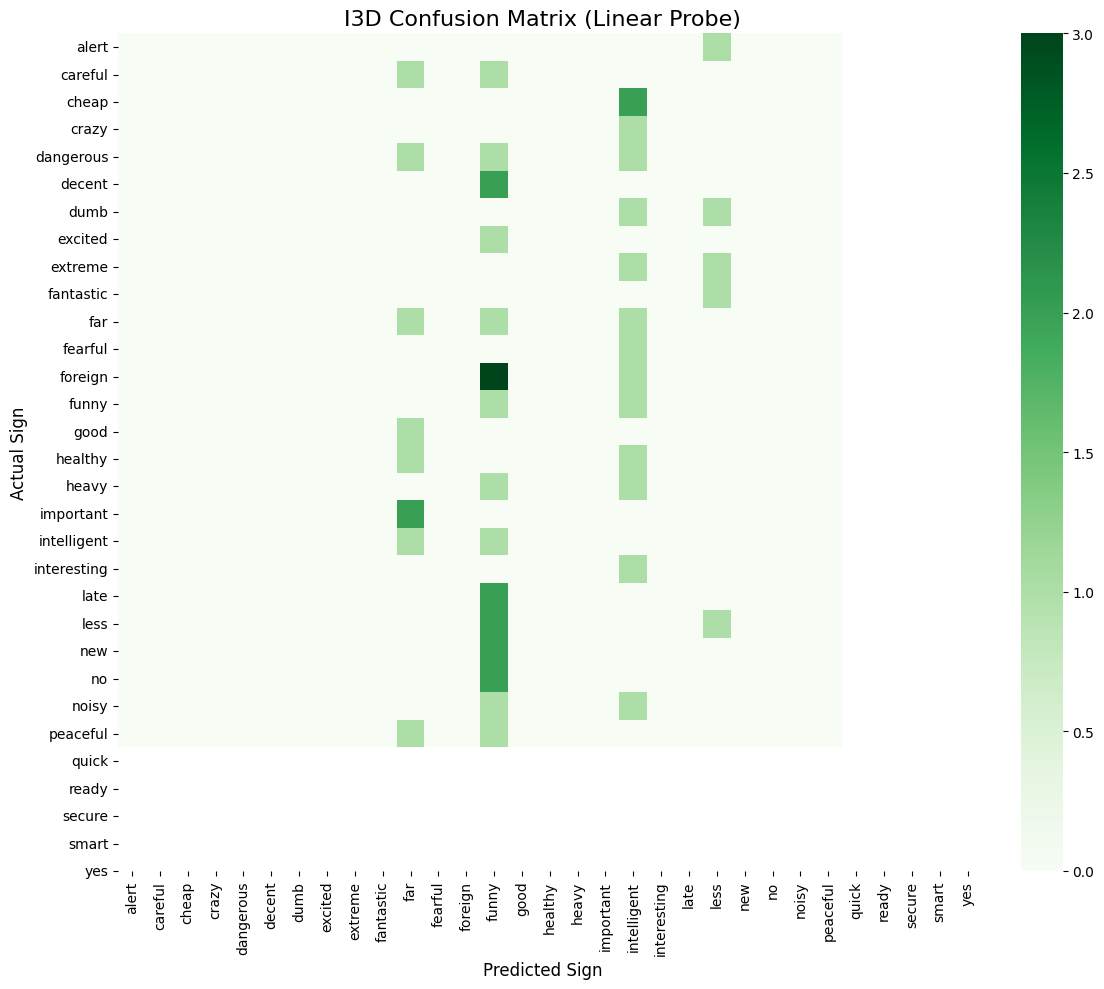

In [6]:
#I3D 
import os
import sys
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
import zipfile
import subprocess

print("--- 🚀 Initializing the Heavyweight I3D Video Experiment ---")

# --- 🛡️ THE BULLETPROOF FIX ---
os.chdir('/kaggle/working')
i3d_path = '/kaggle/working/WLASL/code/I3D/pytorch_i3d.py'
if not os.path.exists(i3d_path):
    print("⚠️ WLASL repository is missing! Redownloading it now...")
    subprocess.run(['rm', '-rf', '/kaggle/working/WLASL'])
    subprocess.run(['git', 'clone', 'https://github.com/dxli94/WLASL.git', '/kaggle/working/WLASL'])
    print("✅ Download complete!")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sys.path.append('/kaggle/working/WLASL/code/I3D')

try:
    from pytorch_i3d import InceptionI3d
    print("✅ Successfully imported I3D model architecture!")
except Exception as e:
    print(f"❌ Critical Import Error: {e}")
    raise e
# ----------------------------------------------------------------

OUTPUT_DIR = '/kaggle/working/i3d_outputs'
CKPT_DIR = '/kaggle/working/i3d_checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# 1. Hunt for the RAW MP4 Videos Folder
video_dirs = glob.glob('/kaggle/input/**/Videos', recursive=True)
if len(video_dirs) > 0:
    raw_videos_dir = video_dirs[0]
    print(f"Found Raw Videos at: {raw_videos_dir}")
else:
    raise FileNotFoundError("Error: Could not find the Videos folder in /kaggle/input!")

class_names = sorted(os.listdir(raw_videos_dir)) 
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
num_classes = len(class_to_idx)
print(f"Discovered {num_classes} classes.")

# 2. Define the I3D RGB Video Dataset
class PSLVideoDataset(Dataset):
    def __init__(self, file_list, target_frames=64, img_size=224, is_train=False):
        self.file_list = file_list
        self.target_frames = target_frames
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        
        # Open the MP4 file using OpenCV
        cap = cv2.VideoCapture(file_path)
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            # Convert from OpenCV BGR to PyTorch RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Resize to 224x224 (I3D Standard)
            frame = cv2.resize(frame, (self.img_size, self.img_size))
            frames.append(frame)
        cap.release()
        
        frames = np.array(frames) # Shape: [Total_Frames, H, W, Channels]
        total_frames = frames.shape[0]
        
        # Handle empty/corrupted videos
        if total_frames == 0:
            frames = np.zeros((self.target_frames, self.img_size, self.img_size, 3), dtype=np.uint8)
            total_frames = self.target_frames
            
        # Pad or sample exactly 64 frames
        if total_frames >= self.target_frames:
            # Evenly sample frames
            indices = np.linspace(0, total_frames - 1, self.target_frames).astype(int)
            frames = frames[indices]
        else:
            # Pad with black frames if too short
            pad_len = self.target_frames - total_frames
            pad_frames = np.zeros((pad_len, self.img_size, self.img_size, 3), dtype=np.uint8)
            frames = np.concatenate([frames, pad_frames], axis=0)

        # Basic Augmentation (Random Horizontal Flip)
        if self.is_train and random.random() > 0.5:
            frames = np.flip(frames, axis=2).copy()

        # Normalize pixels from 0-255 to 0-1
        frames = frames.astype(np.float32) / 255.0
        
        # Reshape for I3D: from [T, H, W, C] to [Channels, Time, Height, Width]
        tensor = torch.from_numpy(frames).permute(3, 0, 1, 2)
        
        # Read the real label from the file path
        parent_folder = os.path.basename(os.path.dirname(file_path))
        label = class_to_idx[parent_folder]
        
        return tensor, torch.tensor(label, dtype=torch.long)

# 3. Prepare Data Loaders (Hunting for MP4s!)
print("\n--- Preparing RGB Video Data Loaders ---")
all_mp4s = glob.glob(f'{raw_videos_dir}/**/*.mp4', recursive=True)

if len(all_mp4s) == 0:
    raise FileNotFoundError("Could not find the .mp4 files! Make sure your WLPSL dataset is attached.")

random.seed(42)
random.shuffle(all_mp4s)

train_size = int(0.8 * len(all_mp4s))
train_files = all_mp4s[:train_size]
test_files = all_mp4s[train_size:]

train_dataset = PSLVideoDataset(train_files, is_train=True)
test_dataset = PSLVideoDataset(test_files, is_train=False)

# BATCH SIZE IS 2 TO PREVENT VRAM CRASHES!
train_loader = DataLoader(train_dataset, batch_size=3, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=3, shuffle=False)

print(f"Data Split: {len(train_dataset)} Training Videos | {len(test_dataset)} Testing Videos")

# 4. Model Injection & Freezing Functions
def get_fresh_i3d_model():
    # Standard I3D is born to predict 400 action classes (Kinetics)
    model = InceptionI3d(400, in_channels=3)
    
    # Hunt for pre-trained I3D weights (if you uploaded them), otherwise load standard
    weight_paths = glob.glob('/kaggle/input/**/*.pt', recursive=True) 
    
    if len(weight_paths) > 0:
        print(f"  -> Found pre-trained weights: {weight_paths[0]}")
        try:
            model.load_state_dict(torch.load(weight_paths[0], map_location=device))
        except:
            print("  -> Could not perfectly map weights. Injecting what fits...")
            pretrained_dict = torch.load(weight_paths[0], map_location=device)
            model_dict = model.state_dict()
            filtered_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
            model_dict.update(filtered_dict)
            model.load_state_dict(model_dict)
    else:
        print("  -> No pre-trained I3D weights found in Kaggle inputs. Starting with an empty I3D Brain!")
        
    # Replace the final 400-class layer with our 31-class layer
    model.replace_logits(num_classes)
    return model.to(device)

def apply_zero_shot(model):
    for param in model.parameters(): param.requires_grad = False

def apply_linear_probe(model):
    for param in model.parameters(): param.requires_grad = False
    # Unfreeze the very last classification layer we just replaced
    for param in model.logits.parameters():
        param.requires_grad = True

def apply_partial_ft(model):
    for param in model.parameters(): param.requires_grad = False
    # Unfreeze the final mixed block of the network
    for param in model.Mixed_5c.parameters(): param.requires_grad = True
    for param in model.logits.parameters(): param.requires_grad = True

def apply_full_ft(model):
    for param in model.parameters(): param.requires_grad = True 
# 5. Training & Evaluation Engine
def run_stage(stage_name, freeze_function, epochs=15, lr=0.001):
    print(f"\n{'='*40}\n  Starting Stage: {stage_name}\n{'='*40}")
    model = get_fresh_i3d_model()
    freeze_function(model)
    
    criterion = nn.CrossEntropyLoss()
    
    if stage_name != "Zero-Shot":
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
        
        for epoch in range(1, epochs + 1):
            model.train()
            total_loss = 0.0
            
            for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                
                # I3D returns a tuple, we only need the first element (logits)
                predictions = model(batch_x)
                if isinstance(predictions, tuple): predictions = predictions[0]
                
                # 🚀 THE FIX: Average the predictions across the 7 time chunks!
                predictions = predictions.mean(dim=-1).squeeze()
                
                loss = criterion(predictions, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
                
            print(f"  Epoch {epoch}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f}")
    
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            if isinstance(outputs, tuple): outputs = outputs[0]
            
            # 🚀 THE FIX: Average the outputs across the time chunks!
            outputs = outputs.mean(dim=-1).squeeze()
            
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    test_acc = (correct / total) * 100
    print(f"  {stage_name} Test Accuracy: {test_acc:.2f}%")
    
    ckpt_path = f"{CKPT_DIR}/{stage_name.replace(' ', '_')}.pth"
    torch.save(model.state_dict(), ckpt_path)
    
    return {'acc': test_acc, 'preds': all_preds, 'labels': all_labels, 'ckpt': ckpt_path}
# 6. Execute the Experiment (EPOCHS ARE LOWERED BECAUSE I3D IS HEAVY!)
results = {}
results['Zero-Shot']    = run_stage("Zero-Shot", apply_zero_shot, epochs=0) 
results['Linear Probe'] = run_stage("Linear Probe", apply_linear_probe, epochs=15, lr=0.001)
results['Partial FT']   = run_stage("Partial FT", apply_partial_ft, epochs=15, lr=0.0005)
results['Full FT']      = run_stage("Full FT", apply_full_ft, epochs=15, lr=0.0001)

# 7. Result Matrix
print("\n" + "="*40 + "\n          🏆 I3D RESULT MATRIX 🏆\n" + "="*40)
best_stage = max(results, key=lambda k: results[k]['acc'])
for stage, data in results.items():
    marker = " <-- BEST!" if stage == best_stage else ""
    print(f"  {stage.ljust(15)} : {data['acc']:>6.2f}% {marker}")

# 8. Confusion Matrix
print("\n--- Generating Confusion Matrix ---")
best_preds, best_labels = results[best_stage]['preds'], results[best_stage]['labels']
cm = confusion_matrix(best_labels, best_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f"I3D Confusion Matrix ({best_stage})", fontsize=16)
plt.xlabel("Predicted Sign", fontsize=12)
plt.ylabel("Actual Sign", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

cm_path = f"{OUTPUT_DIR}/i3d_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
print(f"Saved Confusion Matrix to {cm_path}")

# 9. Zip Export
print("\n--- Zipping Results and Checkpoints ---")
zip_path = '/kaggle/working/I3D_Experiment_Results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir(OUTPUT_DIR): zipf.write(f"{OUTPUT_DIR}/{f}", f"i3d_outputs/{f}")
    for f in os.listdir(CKPT_DIR): zipf.write(f"{CKPT_DIR}/{f}", f"i3d_checkpoints/{f}")

print(f"✅ Success! I3D experiment complete and packaged in '{zip_path}'.")

In [7]:
from IPython.display import FileLink
FileLink('I3D_Experiment_Results.zip')

/kaggle/working/I3D_Experiment_Results.zip